In [1]:
import sys
sys.path.append('../')

In [2]:
import pandas as pd
import random
from tqdm import tqdm
from os.path import join as pjoin
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error

In [3]:
root = '../data/filtered'

In [4]:
xPath = pjoin(root, 'X.h5')
yPath = pjoin(root, 'Y.h5')

X = pd.read_hdf(xPath)
Y = pd.read_hdf(yPath)

In [5]:
Y = pd.concat([Y, X.PHI, X.W_Tar, X.SW], axis = 1)
X = X.drop(['PHI', 'W_Tar', 'SW'], axis = 1)

In [6]:
# scaler_vsh = StandardScaler()
# scaler_phi = StandardScaler()
# scaler_sw = StandardScaler()

# scaler_vsh.fit(Y.VSH.values.reshape(-1, 1))
# scaler_phi.fit(Y.PHI.values.reshape(-1, 1))
# scaler_sw.fit(Y.SW.values.reshape(-1, 1))

# Y.VSH = scaler_vsh.transform(Y.VSH.values.reshape(-1, 1))
# Y.PHI = scaler_phi.transform(Y.PHI.values.reshape(-1, 1))
# Y.SW = scaler_sw.transform(Y.SW.values.reshape(-1, 1))

In [7]:
root = '../data/multitask_processed'

In [8]:
blind_well = random.sample(list(X.UWI.unique()), 10)

In [9]:
blind_X = X[X.UWI.isin(blind_well) == True]
blind_Y = Y[X.UWI.isin(blind_well) == True]

Y = Y[X.UWI.isin(blind_well) == False]
X = X[X.UWI.isin(blind_well) == False]

In [10]:
blind_X.to_hdf(pjoin(root, 'blind_X.h5'), key='X', mode='w')
blind_Y.to_hdf(pjoin(root, 'blind_Y.h5'), key='Y', mode='w')

X.to_hdf(pjoin(root, 'X.h5'), key='X', mode='w')
Y.to_hdf(pjoin(root, 'Y.h5'), key='Y', mode='w')

In [11]:
import numpy as np
from tqdm import tqdm
import patchify as pf
from sklearn.preprocessing import StandardScaler

def create_patches(X, Y, well_names, data_config, num_features):
    # get parameters of patch
    patch_size = data_config['patch']['patch_size']
    stride = data_config['patch']['stride']
    well_name_column = data_config['well_name_column']
    x_patches, y_patches = [], []

    # iterate over wells
    for well in tqdm(well_names, desc='Creating Patches'):

        # get data of each well
        well_x = X[X[well_name_column] == well]
        well_y = Y.loc[well_x.index]

        # drop well name column
        well_x = well_x.drop([well_name_column], axis=1)

        # create patches if well has data more than patch size
        if well_x.shape[0] >= patch_size:

            # create patches
            well_x_patches = pf.patchify(well_x.values, (patch_size, num_features), step=stride)
            well_x_patches = well_x_patches.squeeze()

            well_y_patches = pf.patchify(well_y.values, (patch_size, well_y.values.shape[-1]), step=stride)
            well_y_patches = well_y_patches.squeeze()

            if well_x_patches.ndim == 3:
                for i, j in zip(well_x_patches, well_y_patches):
                    x_patches.append(i)
                    y_patches.append(j)
                    
            #if well has only one patch
            else:
                x_patches.append(well_x_patches)
                y_patches.append(well_y_patches)

    return np.array(x_patches), np.array(y_patches)

import numpy as np
import pandas as pd
from os.path import join as pjoin

import torch

from sklearn.model_selection import train_test_split

def prepare_data(config, blind=False):
    print("Preparing the data...")

    # Load the parameters from the config file
    data_config = config['data']
    root = config['root']

    data_config['x_file_name'] = data_config['x_file_name'] if not config['model']['use_lora'] else 'lora_' + data_config['x_file_name']
    data_config['y_file_name'] = data_config['y_file_name'] if not config['model']['use_lora'] else 'lora_' + data_config['y_file_name']

    # Load the path to the processed data
    x_path = pjoin(root, data_config['processed_data_path'], data_config['x_file_name'])
    y_path = pjoin(root, data_config['processed_data_path'], data_config['y_file_name'])

    # Load the data from hdf5 files
    X = pd.read_hdf(x_path)
    Y = pd.read_hdf(y_path)

    # Get the unique well names
    well_names = X.UWI.unique()

    # Drop the columns that are not needed in the training
    X.drop(data_config['drop_columns'], axis=1, inplace=True)

    # Scale the data
    X = scale_data(X, data_config)

    # check if the data is patch based, if yes, create patches else model will be trained on the point data
    if data_config['patch_based']:

        # Create patches from the data
        num_features = X.shape[1] - 1
        x_patches, y_patches = create_patches(X, Y, well_names, data_config, num_features)

        # Get the number of classes
        num_classes = len(np.unique(y_patches[:, :, 0]))

        if not blind:
            # Split the data into train and validation
            (
                x_train, 
                x_val, 
                y_train, 
                y_val
            ) = train_test_split(
                x_patches, 
                y_patches, 
                test_size=data_config['split_size'], 
                random_state=config['random_state']
            )

            # Convert the data to PyTorch tensors
            x_train = torch.tensor(x_train).float()
            y_train = torch.tensor(y_train)
            x_val = torch.tensor(x_val).float()
            y_val = torch.tensor(y_val)
        else:
            x_train = torch.tensor(x_patches).float()
            y_train = torch.tensor(y_patches)
            x_val = None
            y_val = None
    else:
        # drop the well name column
        X = X.drop([data_config['well_name_column']], 
                   axis=1)
        
        # Get the number of classes
        num_classes = len(np.unique(Y))

        # Split the data into train and validation
        (
            x_train, 
            x_val, 
            y_train, 
            y_val
        ) = train_test_split(
            X, 
            Y, 
            test_size=data_config['split_size'], 
            random_state=config['random_state']
        )

    print(f"Number of classes: {num_classes} and shape of x_train: {x_train.shape}")
    return x_train, x_val, y_train, y_val, num_classes

def scale_data(X, data_config):
    if 'lat' in data_config['scaled_columns']:
        lat_min, lat_max = X.lat.min(), X.lat.max()
        X.lat = (X.lat - lat_min) / (lat_max - lat_min)

    if 'lng' in data_config['scaled_columns']:
        lng_min, lng_max = X.lng.min(), X.lng.max()
        X.lng = (X.lng - lng_min) / (lng_max - lng_min)

    if 'DEPT' in data_config['scaled_columns']:
        depth_min, depth_max = X.DEPT.min(), X.DEPT.max()
        X.DEPT = (X.DEPT - depth_min) / (depth_max - depth_min)

    if 'ILD' in data_config['scaled_columns']:
        scaler_ild = StandardScaler()
        X.ILD = scaler_ild.fit_transform(X.ILD.values.reshape(-1, 1))

    if 'GR' in data_config['scaled_columns']:
        scaler_gr = StandardScaler()
        X.GR = scaler_gr.fit_transform(X.GR.values.reshape(-1, 1))

    if 'NPHI' in data_config['scaled_columns']:
        scaler_nphi = StandardScaler()
        X.NPHI = scaler_nphi.fit_transform(X.NPHI.values.reshape(-1, 1))

    if 'DPHI' in data_config['scaled_columns']:
        scaler_dphi = StandardScaler()
        X.DPHI = scaler_dphi.fit_transform(X.DPHI.values.reshape(-1, 1))

    if 'W_Tar' in data_config['scaled_columns']:
        scaler_w_tar = StandardScaler()
        X.W_Tar = scaler_w_tar.fit_transform(X.W_Tar.values.reshape(-1, 1))

    if 'SW' in data_config['scaled_columns']:
        scaler_sw = StandardScaler()
        X.SW = scaler_sw.fit_transform(X.SW.values.reshape(-1, 1))

    if 'VSH' in data_config['scaled_columns']:
        scaler_vsh = StandardScaler()
        X.VSH = scaler_vsh.fit_transform(X.VSH.values.reshape(-1, 1))

    if 'VSH_CALC' in data_config['scaled_columns']:
        scaler_vsh_calc = StandardScaler()
        X.VSH_CALC = scaler_vsh_calc.fit_transform(X.VSH_CALC.values.reshape(-1, 1))

    if 'PHI' in data_config['scaled_columns']:
        scaler_phi = StandardScaler()
        X.PHI = scaler_phi.fit_transform(X.PHI.values.reshape(-1, 1))

    return X

In [12]:
config = {}
config['data'] = {}
config['model'] = {}
config['data']['patch'] = {}

config['model']['use_lora'] = False

config['data']['x_file_name'] = 'X.h5'
config['data']['y_file_name'] = 'Y.h5'
config['data']['processed_data_path'] = 'data/multitask_processed'
config['data']['drop_columns'] = ['lat','lng','DEPT', 'RW']
config['data']['scaled_columns'] = ['GR','NPHI','DPHI','ILD','VSH']
config['data']['patch_based'] = True
config['data']['patch']['patch_size'] = 150
config['data']['patch']['stride'] = 150
config['data']['well_name_column'] = 'UWI'
config['data']['split_size'] = 0.2
config['data']['lithology_classes'] = {'Sand': 0,
                                       'ShalySand': 1,
                                       'SandyShale': 2,
                                       'Shale': 3,
                                       'Coal': 4,
                                       'CementedSand': 5}

config['root'] = '..'
config['random_state'] = 42

batch_size = 64

In [13]:
x_train, x_val, y_train, y_val, num_classes = prepare_data(config)

Preparing the data...


Creating Patches: 100%|██████████| 1002/1002 [00:23<00:00, 42.02it/s]


Number of classes: 6 and shape of x_train: torch.Size([1265, 150, 5])


In [14]:
from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader

In [15]:
train_dataset = TensorDataset(x_train, y_train)
trainloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

val_dataset = TensorDataset(x_val, y_val)
valloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=True)

In [16]:
regression_criterion = torch.nn.MSELoss()
classification_criterion = torch.nn.CrossEntropyLoss()

In [17]:
from model.multi_task_vit import build_model

In [18]:
config['data']['num_features'] = x_train.shape[-1]
config['model']['activation'] = 'relu'
config['model']['dim'] = 150
config['model']['depth'] = 1
config['model']['heads'] = 4
config['model']['mlp_dim'] = 256
config['model']['channels'] = 1
config['model']['dim_head'] = 128

config['trainer'] = {}
config['trainer']['device'] = 'cuda'

In [19]:
model = build_model(config)
model = model.to(config['trainer']['device'])

Building the model...


In [20]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [21]:
from matplotlib import pyplot as plt

In [22]:
import numpy as np
from tqdm import tqdm

import torch
from einops import rearrange
import torch.nn as nn

from sklearn.metrics import confusion_matrix

from utils.misc import update_best_metrices

def train_engine(
        epoch, model, 
        train_loader, 
        regression_criterion,
        classification_criterion,
        optimizer, 
        num_epochs, 
        loss_weights,
        device
    ):

    train_loss = 0.0
    lith_train_loss = 0.0
    phi_train_loss = 0.0
    rw_train_loss = 0.0
    sw_train_loss = 0.0
    train_correct = 0

    gt, pred = [], []

    model.train()
    for batch_inputs, batch_labels in tqdm(train_loader, 
                                           total=len(train_loader), 
                                           desc=f"Train - Epoch {epoch+1}/{num_epochs}"):
        optimizer.zero_grad()

        batch_inputs = batch_inputs.to(device)
        batch_labels = batch_labels.to(device).to(torch.float32)

        # Forward pass
        lith_output, phi_output, rw_output, sw_output = model(batch_inputs)

        lith_batch_labels = batch_labels[:, :, 0]
        phi_batch_labels = batch_labels[:, :, 1:2]
        rw_batch_labels = batch_labels[:, :, 2:3]
        sw_batch_labels = batch_labels[:, :, 3:]

        lith_batch_labels = lith_batch_labels.long()
        lith_output_ = rearrange(lith_output, 'b n d -> b d n')
        lith_loss = classification_criterion(lith_output_, lith_batch_labels)

        phi_loss = regression_criterion(phi_output, phi_batch_labels)
        rw_loss = regression_criterion(rw_output, rw_batch_labels)

        sw_batch_labels_gradient = torch.gradient(sw_batch_labels, dim = 1)[0]
        sw_output_gradient = torch.gradient(sw_output, dim = 1)[0]
        sw_loss = regression_criterion(sw_output, sw_batch_labels)
        sw_gradient_loss = regression_criterion(sw_output_gradient, sw_batch_labels_gradient)

        loss = (
            (lith_loss*loss_weights[0]) +
            (phi_loss*loss_weights[1]) +
            (rw_loss*loss_weights[2]) +
            (sw_loss*loss_weights[3]) +
            (sw_gradient_loss)
        )

        # Backward pass and optimization
        loss.backward()
        optimizer.step()

        # Calculate training accuracy
        predicted = torch.argmax(nn.Softmax(dim = -1)(lith_output), dim=-1)
        train_correct += (((lith_batch_labels == predicted).sum(-1).float().mean().item())/batch_inputs.shape[1])*100

        gt.append(lith_batch_labels.cpu())
        pred.append(predicted.cpu())

        train_loss += loss.item()
        lith_train_loss += lith_loss.item()
        phi_train_loss += phi_loss.item()
        rw_train_loss += rw_loss.item()
        sw_train_loss += sw_loss.item()
    
    cm = confusion_matrix(torch.cat(gt, dim=0).view(-1), torch.cat(pred, dim=0).view(-1))

    # Calculate average training loss and accuracy for the epoch
    train_loss /= len(train_loader)
    lith_train_loss /= len(train_loader)
    phi_train_loss /= len(train_loader)
    rw_train_loss /= len(train_loader)
    sw_train_loss /= len(train_loader)

    train_accuracy = train_correct / len(train_loader)

    return train_loss, lith_train_loss, phi_train_loss, rw_train_loss, sw_train_loss, train_accuracy, cm

def validation_engine(
        epoch, 
        model, 
        val_loader, 
        regression_criterion,
        classification_criterion,
        num_epochs, 
        loss_weights,
        device
    ):
    
    val_loss = 0.0
    lith_val_loss = 0.0
    phi_val_loss = 0.0
    rw_val_loss = 0.0
    sw_val_loss = 0.0
    val_correct = 0

    gt_val, pred_val = [], []
    
    # Evaluate on the validation set
    model.eval()
    for batch_inputs_val, batch_labels_val in tqdm(val_loader, 
                                                   total=len(val_loader), 
                                                   desc=f"Val - Epoch {epoch+1}/{num_epochs}"):
        
        batch_inputs_val = batch_inputs_val.to(device)
        batch_labels_val = batch_labels_val.to(device)

        with torch.no_grad():
            lith_output_val, phi_output_val, rw_output_val, sw_output_val = model(batch_inputs_val)

        lith_batch_labels_val = batch_labels_val[:, :, 0]
        phi_batch_labels_val = batch_labels_val[:, :, 1:2]
        rw_batch_labels_val = batch_labels_val[:, :, 2:3]
        sw_batch_labels_val = batch_labels_val[:, :, 3:]

        lith_batch_labels_val = lith_batch_labels_val.long()
        lith_output_val_ = rearrange(lith_output_val, 'b n d -> b d n')
        lith_loss_val = classification_criterion(lith_output_val_, lith_batch_labels_val)

        phi_loss_val = regression_criterion(phi_output_val, phi_batch_labels_val)

        rw_batch_labels_val_gradient = torch.gradient(rw_batch_labels_val, dim = 1)[0]
        rw_output_val_gradient = torch.gradient(rw_output_val, dim = 1)[0]
        rw_loss_val = regression_criterion(rw_output_val, rw_batch_labels_val)
        rw_gradient_loss_val = regression_criterion(rw_output_val_gradient, rw_batch_labels_val_gradient)
        
        sw_batch_labels_val_gradient = torch.gradient(sw_batch_labels_val, dim = 1)[0]
        sw_output_val_gradient = torch.gradient(sw_output_val, dim = 1)[0]
        sw_loss_val = regression_criterion(sw_output_val, sw_batch_labels_val)
        sw_gradient_loss_val = regression_criterion(sw_output_val_gradient, sw_batch_labels_val_gradient)

        loss_val = (
            (lith_loss_val*loss_weights[0]) +
            (phi_loss_val*loss_weights[1]) +
            (rw_loss_val*loss_weights[2]) +
            (sw_loss_val*loss_weights[3]) +
            (sw_gradient_loss_val) +
            (rw_gradient_loss_val)
        )

        val_loss += loss_val.item()
        lith_val_loss += lith_loss_val.item()
        phi_val_loss += phi_loss_val.item()
        rw_val_loss += rw_loss_val.item()
        sw_val_loss += sw_loss_val.item()

        # Calculate validation accuracy
        predicted_val = torch.argmax(nn.Softmax(dim = -1)(lith_output_val), dim=-1)
        val_correct += (((lith_batch_labels_val == predicted_val).sum(-1).float().mean().item())/batch_inputs_val.shape[1])*100

        gt_val.append(lith_batch_labels_val.cpu())
        pred_val.append(predicted_val.cpu())

    cm_val = confusion_matrix(torch.cat(gt_val, dim=0).view(-1), torch.cat(pred_val, dim=0).view(-1))

    # Calculate average validation loss and accuracy for the epoch
    val_loss /= len(val_loader)
    lith_val_loss /= len(val_loader)
    phi_val_loss /= len(val_loader)
    rw_val_loss /= len(val_loader)
    sw_val_loss /= len(val_loader)

    val_accuracy = val_correct / len(val_loader)

    return val_loss, lith_val_loss, phi_val_loss, rw_val_loss, sw_val_loss, val_accuracy, cm_val

/home/nasim/anaconda3/envs/ML/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [23]:
config['model']['loss_weights'] = [1, 1, 1, 10]

In [24]:
train_losses = []
val_losses = []

train_lith_losses = []
val_lith_losses = []

train_phi_losses = []
val_phi_losses = []

train_rw_losses = []
val_rw_losses = []

train_sw_losses = []
val_sw_losses = []

train_accuracies = []
val_accuracies = []

best_loss = np.inf

best_cm_val = None
best_cm = None
best_model_chkpt = None
best_optim_chkpt = None
best_epoch = 1
best_accuracy = 0.0

for epoch in range(200):
    train_loss, lith_train_loss, phi_train_loss, rw_train_loss, sw_train_loss, train_accuracy, cm = train_engine(epoch, 
                                                model, 
                                                trainloader, 
                                                regression_criterion,
                                                classification_criterion,
                                                optimizer, 
                                                200,
                                                config['model']['loss_weights'],
                                                'cuda')
    
    val_loss, lith_val_loss, phi_val_loss, rw_val_loss, sw_val_loss, val_accuracy, cm_val = validation_engine(epoch, 
                                                model, 
                                                valloader, 
                                                regression_criterion,
                                                classification_criterion,
                                                200,
                                                config['model']['loss_weights'],
                                                'cuda')
    train_losses.append(train_loss)
    
    train_lith_losses.append(lith_train_loss)
    train_phi_losses.append(phi_train_loss)
    train_rw_losses.append(rw_train_loss)
    train_sw_losses.append(sw_train_loss)
    train_accuracies.append(train_accuracy)

    val_losses.append(val_loss)
    val_lith_losses.append(lith_val_loss)
    val_phi_losses.append(phi_val_loss)
    val_rw_losses.append(rw_val_loss)
    val_sw_losses.append(sw_val_loss)
    val_accuracies.append(val_accuracy)

    # Print the progress for the current epoch
    print(f"Epoch {epoch+1}/{200}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")
    
    (
        best_loss, 
        best_accuracy, 
        best_epoch, 
        best_cm, 
        best_cm_val, 
        best_model_chkpt, 
        best_optim_chkpt
    ) = update_best_metrices(
        val_loss, 
        val_accuracy, 
        epoch, 
        cm, 
        cm_val, 
        model, 
        optimizer, 
        best_loss, 
        best_accuracy, 
        best_epoch, 
        best_cm, 
        best_cm_val, 
        best_model_chkpt, 
        best_optim_chkpt
    )

    if epoch - (best_epoch) > 20:
        print("Early stopping")
        break

Val - Epoch 1/200: 100%|██████████| 5/5 [00:00<00:00, 64.75it/s]


Epoch 1/200, Train Loss: 1.9114, Val Loss: 1.2465
Model Performance Improved from epoch no. 1


Val - Epoch 2/200: 100%|██████████| 5/5 [00:00<00:00, 66.34it/s]


Epoch 2/200, Train Loss: 0.9563, Val Loss: 0.7838
Model Performance Improved from epoch no. 0


Val - Epoch 3/200: 100%|██████████| 5/5 [00:00<00:00, 65.30it/s]


...

Epoch 56/200, Train Loss: 0.1514, Val Loss: 0.1826


Val - Epoch 57/200: 100%|██████████| 5/5 [00:00<00:00, 64.38it/s]


Epoch 57/200, Train Loss: 0.1414, Val Loss: 0.1675


Val - Epoch 58/200: 100%|██████████| 5/5 [00:00<00:00, 61.91it/s]

Epoch 58/200, Train Loss: 0.1465, Val Loss: 0.1745
Early stopping


In [25]:
from matplotlib import pyplot as plt

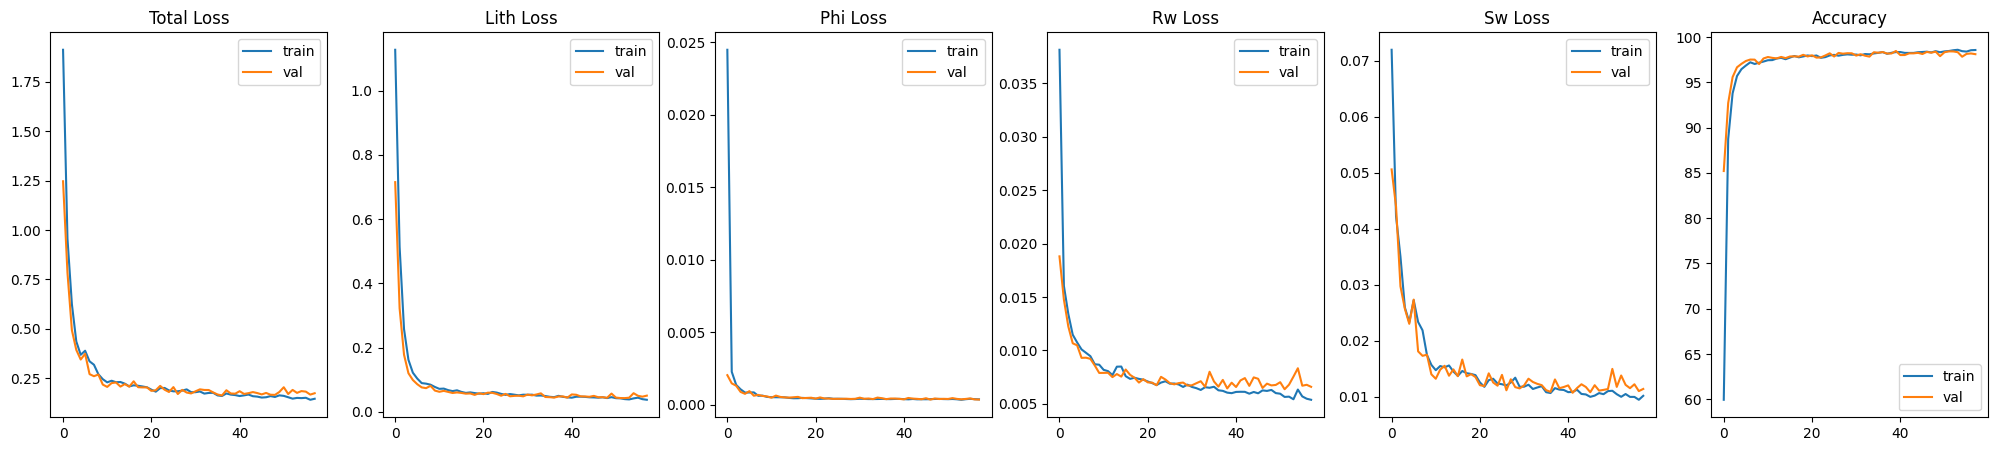

In [26]:
_, ax = plt.subplots(1, 6, figsize=(25, 5))
ax[0].plot(train_losses, label='train')
ax[0].plot(val_losses, label='val')
ax[0].set_title('Total Loss')
ax[0].legend()

ax[1].plot(train_lith_losses, label='train')
ax[1].plot(val_lith_losses, label='val')
ax[1].set_title('Lith Loss')
ax[1].legend()

ax[2].plot(train_phi_losses, label='train')
ax[2].plot(val_phi_losses, label='val')
ax[2].set_title('Phi Loss')
ax[2].legend()

ax[3].plot(train_rw_losses, label='train')
ax[3].plot(val_rw_losses, label='val')
ax[3].set_title('Rw Loss')
ax[3].legend()

ax[4].plot(train_sw_losses, label='train')
ax[4].plot(val_sw_losses, label='val')
ax[4].set_title('Sw Loss')
ax[4].legend()

ax[5].plot(train_accuracies, label='train')
ax[5].plot(val_accuracies, label='val')
ax[5].set_title('Accuracy')
ax[5].legend()

plt.show()

In [27]:
model.load_state_dict(best_model_chkpt)

<All keys matched successfully>

In [28]:
# torch.save({
#     'model_state_dict': best_model_chkpt,
# }, '../vsh_phi_sw.pt')

In [29]:
config['data']['x_file_name'] = 'blind_X.h5'
config['data']['y_file_name'] = 'blind_Y.h5'
x_train, _, y_train, _, num_classes = prepare_data(config)

blind_dataset = TensorDataset(x_train, y_train)
blind_loader = DataLoader(blind_dataset, batch_size=batch_size, shuffle=True)

Preparing the data...


Creating Patches: 100%|██████████| 10/10 [00:00<00:00, 502.49it/s]

Number of classes: 6 and shape of x_train: torch.Size([12, 150, 5])


In [30]:
mae_criterion = torch.nn.L1Loss()

In [31]:
blind_loader = valloader

In [32]:
model.eval()
phi_loss = 0
rw_loss = 0
sw_loss = 0
for inp, gt in blind_loader:
    lith,phi,rw,sw = model(inp.to('cuda'))

    phi_loss += mae_criterion(phi.squeeze(), gt[:, :, 1].cuda()).item()
    rw_loss += mae_criterion(rw.squeeze(), gt[:, :, 2].cuda()).item()
    sw_loss += mae_criterion(sw.squeeze(), gt[:, :, 3].cuda()).item()

print(phi_loss/len(blind_loader))
print(rw_loss/len(blind_loader))
print(sw_loss/len(blind_loader))

0.013526603130443543
0.025447002310604556
0.06115242412102275


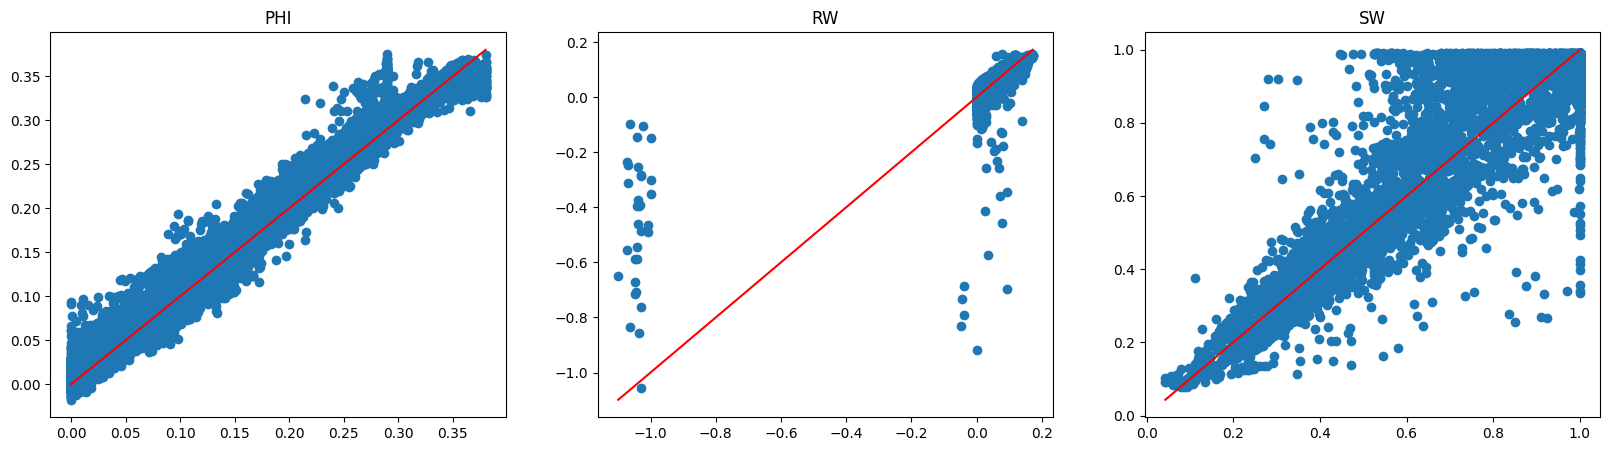

In [33]:
_, ax = plt.subplots(1, 3, figsize=(20, 5))

ax[0].scatter(gt[:, :, 1].reshape(-1), phi[:, :].cpu().detach().numpy().reshape(-1))
ax[0].plot([gt[:, :, 1].min().item(), gt[:, :, 1].max().item()], [gt[:, :, 1].min().item(), gt[:, :, 1].max().item()], color='red')
ax[0].set_title('PHI')

ax[1].scatter(gt[:, :, 2].reshape(-1), rw[:, :].cpu().detach().numpy().reshape(-1))
ax[1].plot([gt[:, :, 2].min().item(), gt[:, :, 2].max().item()], [gt[:, :, 2].min().item(), gt[:, :, 2].max().item()], color='red')
ax[1].set_title('RW')

ax[2].scatter(gt[:, :, 3].reshape(-1), sw[:, :].cpu().detach().numpy().reshape(-1))
ax[2].plot([gt[:, :, 3].min().item(), gt[:, :, 3].max().item()], [gt[:, :, 3].min().item(), gt[:, :, 3].max().item()], color='red')
ax[2].set_title('SW')

plt.show()

In [34]:
# check = {}
# for i, (inp, gt) in enumerate(blind_loader):
#     temp = {}
#     cls,phi,sw = model(inp.to('cuda'))
#     for j, (sw_pred, sw_gt, phi_pred, phi_gt) in enumerate(zip(sw.squeeze(), gt[:, :, 2].cuda(), phi.squeeze(), gt[:, :, 1].cuda())):
#         if mae_criterion(sw_pred, sw_gt)<0.02:
#             temp[j] = mae_criterion(sw_pred, sw_gt)
#             plt.plot(sw_pred.cpu().detach().numpy(), label='pred')
#             plt.plot(sw_gt.cpu().detach().numpy(), label='gt')
#             plt.legend()
#             plt.ylim(0, 1.1)
#             plt.show()

#             plt.plot(phi_pred.cpu().detach().numpy(), label='pred')
#             plt.plot(phi_gt.cpu().detach().numpy(), label='gt')
#             plt.legend()
#             plt.show()

#             print("="*100)
#     check[i] = temp

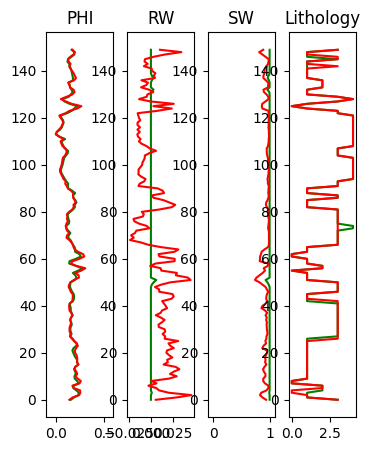

In [35]:
rand_idx = np.random.randint(gt.shape[0])
_, ax = plt.subplots(1, 4, figsize=(4, 5))
ax[0].plot(gt[rand_idx, :, 1].cpu().numpy(), list(range(len(gt[rand_idx, :, 1]))), label='gt', color='green')
ax[0].plot(phi[rand_idx, :].cpu().detach().numpy(), list(range(len(gt[rand_idx, :, 1]))), label='pred', color='red')
ax[0].set_title('PHI')
ax[0].set_xlim(-0.1, 0.6)

ax[1].plot(gt[rand_idx, :, 2].cpu().numpy(), list(range(len(gt[rand_idx, :, 2]))), label='gt', color='green')
ax[1].plot(rw[rand_idx, :].cpu().detach().numpy(), list(range(len(gt[rand_idx, :, 2]))), label='pred', color='red')
ax[1].set_title('RW')

ax[2].plot(gt[rand_idx, :, 3].cpu().numpy(), list(range(len(gt[rand_idx, :, 3]))), label='gt', color='green')
ax[2].plot(sw[rand_idx, :].cpu().detach().numpy(), list(range(len(gt[rand_idx, :, 3]))), label='pred', color='red')
ax[2].set_title('SW')
ax[2].set_xlim(-0.1, 1.1)

ax[3].plot(gt[rand_idx, :, 0].cpu().numpy(), list(range(len(gt[rand_idx, :, 0]))), label='gt', color='green')
ax[3].plot(torch.argmax(lith.softmax(-1), -1)[rand_idx, :].cpu().detach().numpy(), list(range(len(gt[rand_idx, :, 0]))), label='pred', color='red')
ax[3].set_title('Lithology')

plt.show()